# Supplementary: Ridge regression details

| Panel | What |
|-------|------|
| A | Full beta profile — all 8 waveform features for Pre/Post LFP Amp & Std |
| B | Top target × feature combos with large effect and mixed cell direction |
| C | Pre vs post-spike β correlation — same waveform → LFP relationship at both timescales |

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from pop_ridge_utils import (
    merge_hpf_targets,
    aggregate_population,
    run_population_tests,
    run_r2_tests,
    plot_beta_full_summary,
    plot_beta_heterogeneity_top_combos,
    plot_beta_pre_post_scatter,
)
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
ALPHA     = 0.05
MIN_CELLS = 5

In [2]:
all_results, cell_ids, target_names, target_labels, predictor_sets = merge_hpf_targets(
    RIDGE_PICKLE_DIR, FEAT_LABELS,
)

r2_pop, sig_pop, beta_pop = aggregate_population(
    all_results, cell_ids, target_names, predictor_sets)

df_r2 = run_r2_tests(
    r2_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, alpha=ALPHA,
)
sig_r2_targets = (
    df_r2[df_r2['sig_r2'] & (df_r2['predictor_set'] == 'Waveform only')]
    ['target'].tolist()
)

df_tests = run_population_tests(
    beta_pop, target_names, target_labels,
    min_cells=MIN_CELLS, alpha=ALPHA,
    sig_r2_targets=sig_r2_targets,
)

print('Significant R² targets (Waveform only):', sig_r2_targets)
print(f'Cells: {len(cell_ids)}')

Merged: 37 cells  |  18 targets (Pre+Post abs + HPF amp/std, no BL-corrected or Δ)
R² > 0 Wilcoxon: 36 (target × predictor_set) pairs  |  p<0.05: 14  (each target independent, no cross-target correction)
      target_label      predictor_set  n_cells  median_r2  mean_r2    p_str stars
       Pre LFP Amp      Waveform only       37   0.034011 0.077546 < 0.0001   ***
       Pre LFP Amp Waveform + Log ISI       37   0.044731 0.085571 < 0.0001   ***
 Pre LFP Amp (HPF)      Waveform only       37   0.003837 0.029959   0.0025    **
 Pre LFP Amp (HPF) Waveform + Log ISI       37   0.006317 0.037203   0.0002   ***
       Pre LFP Std      Waveform only       37   0.005885 0.030551 < 0.0001   ***
       Pre LFP Std Waveform + Log ISI       37   0.011401 0.039090 < 0.0001   ***
 Pre LFP Std (HPF) Waveform + Log ISI       37   0.001841 0.012021   0.0094    **
      Post LFP Amp      Waveform only       37   0.027957 0.076438 < 0.0001   ***
      Post LFP Amp Waveform + Log ISI       37   0.040640 

## Panel A — Full beta profile (all 8 waveform features)

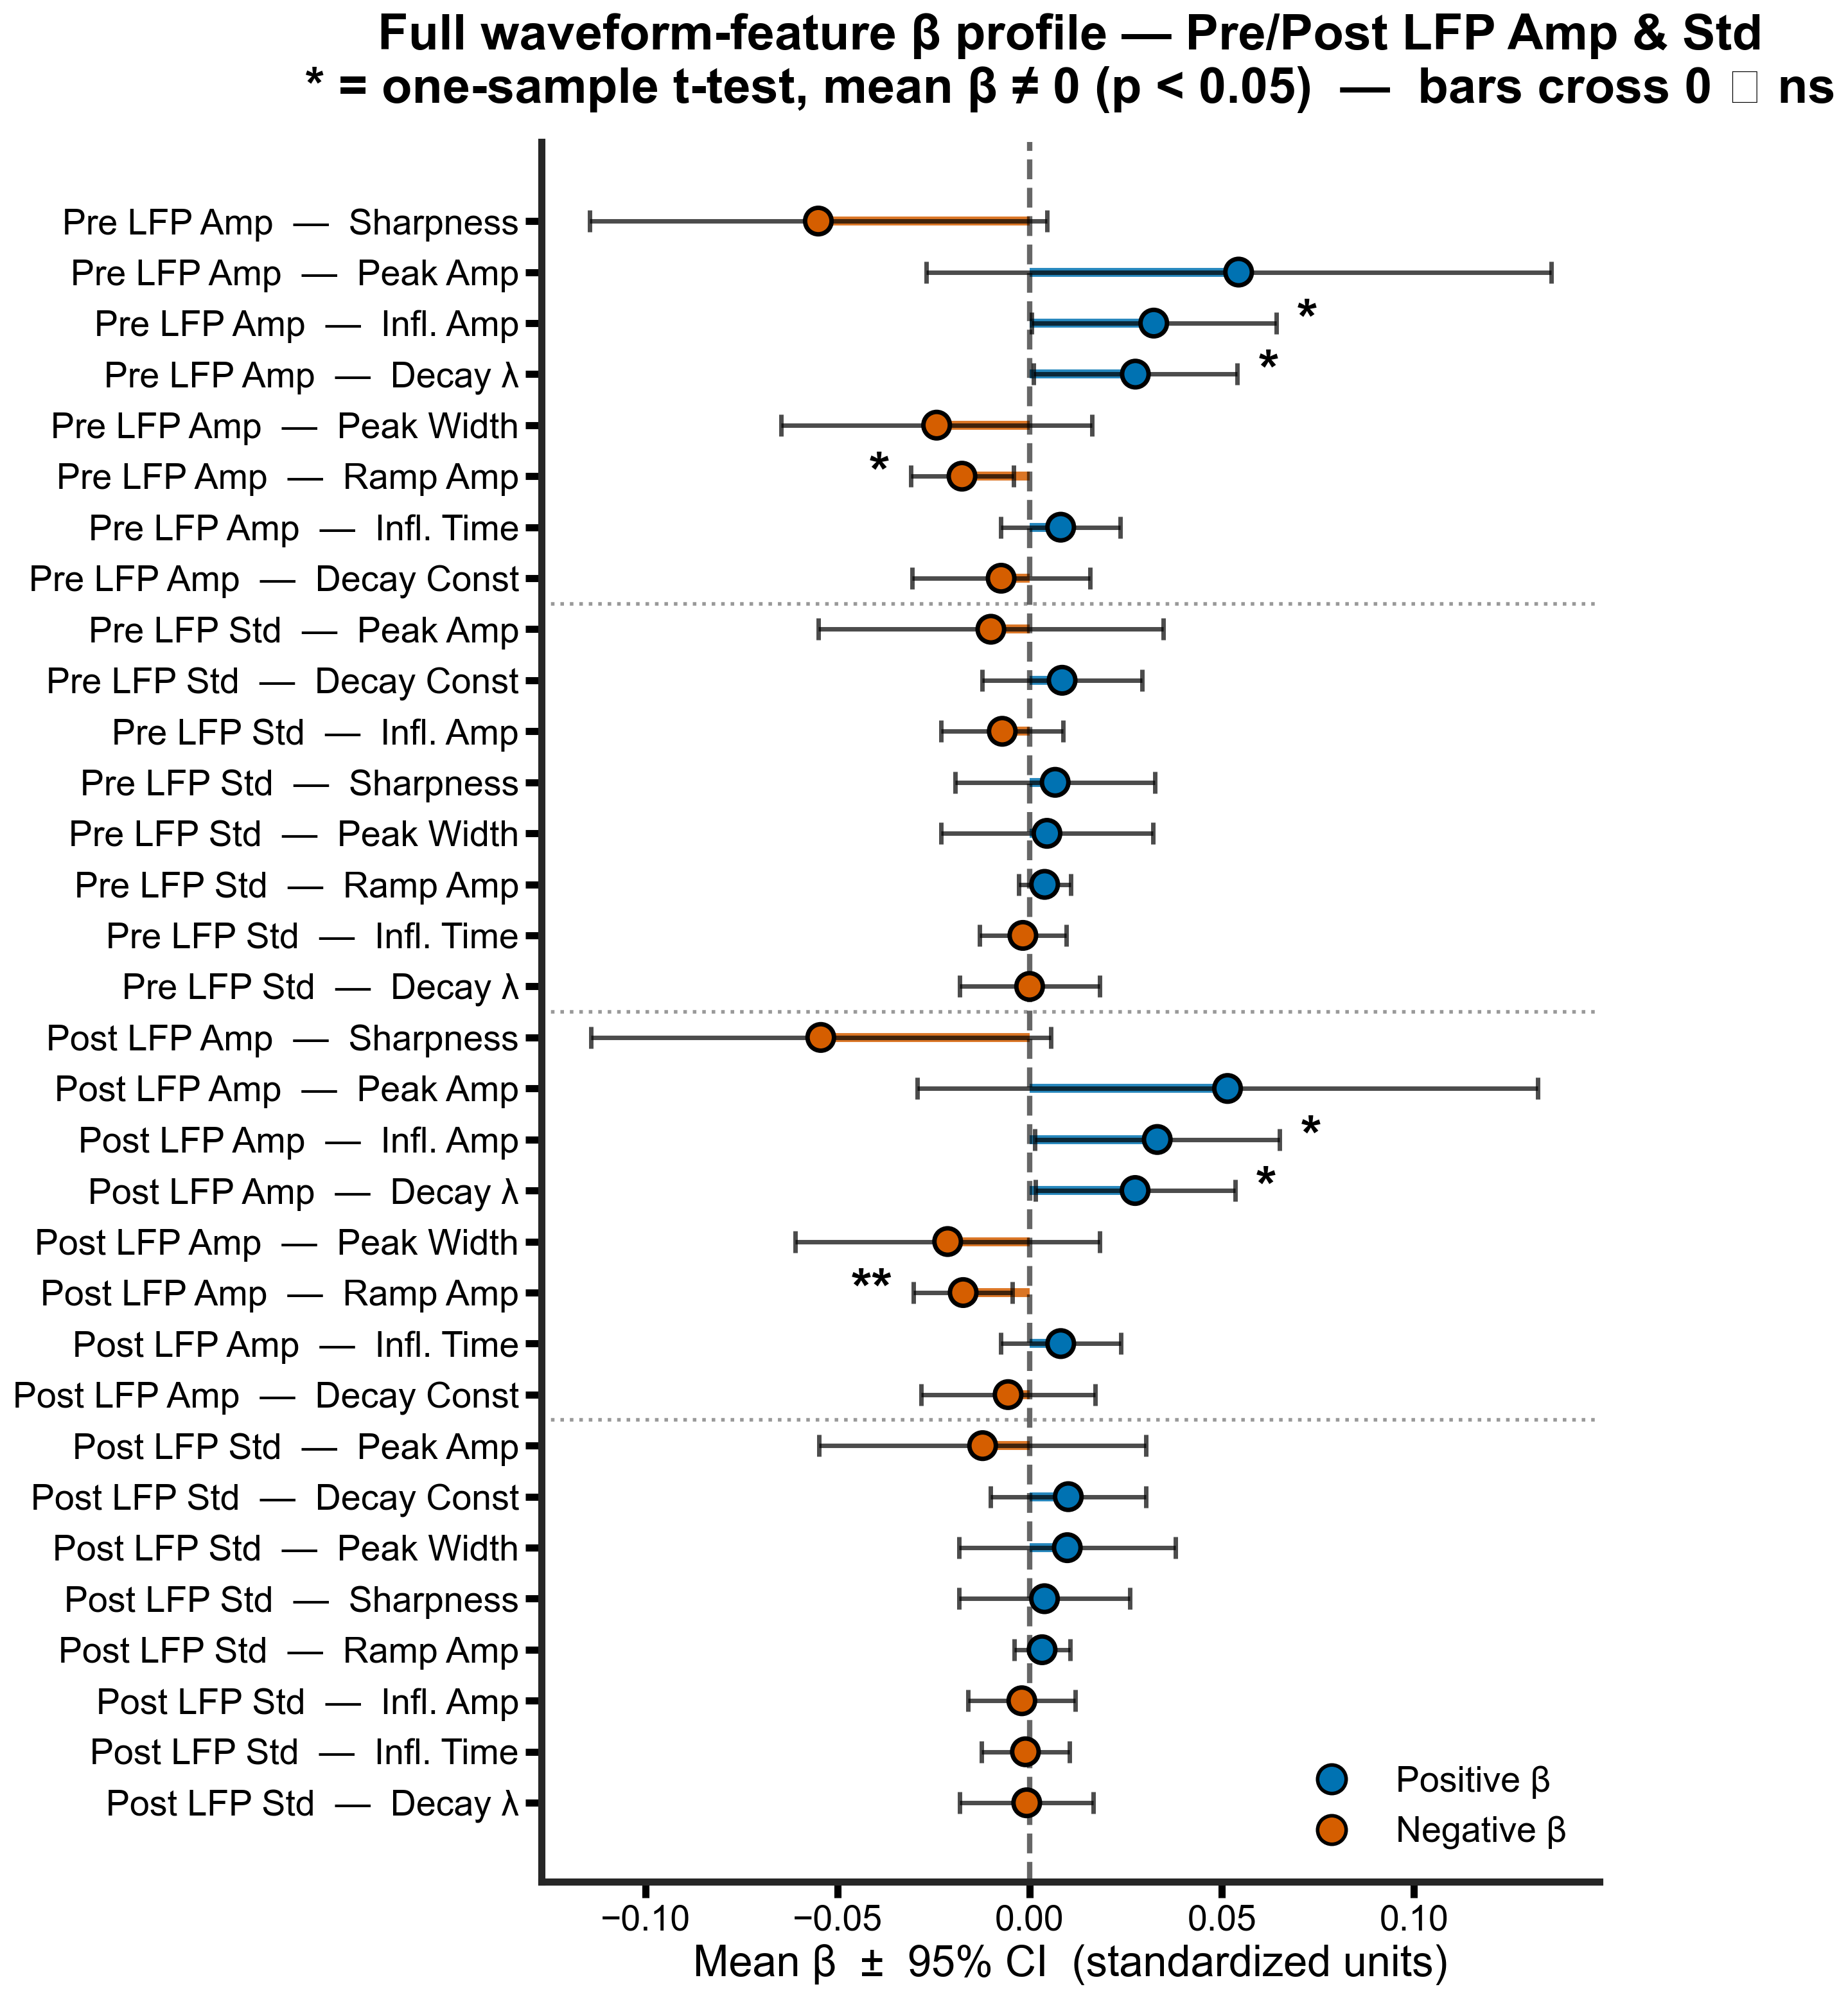

(<Figure size 1300x1600 with 1 Axes>,
 <Axes: title={'center': 'Full waveform-feature β profile — Pre/Post LFP Amp & Std\n* = one-sample t-test, mean β ≠ 0 (p < 0.05)  —  bars cross 0 ⟺ ns'}, xlabel='Mean β  ±  95% CI  (standardized units)'>)

In [3]:
plot_beta_full_summary(df_tests, target_names, target_labels)

## Panel B — Top target × feature combos: large effect, mixed cell direction

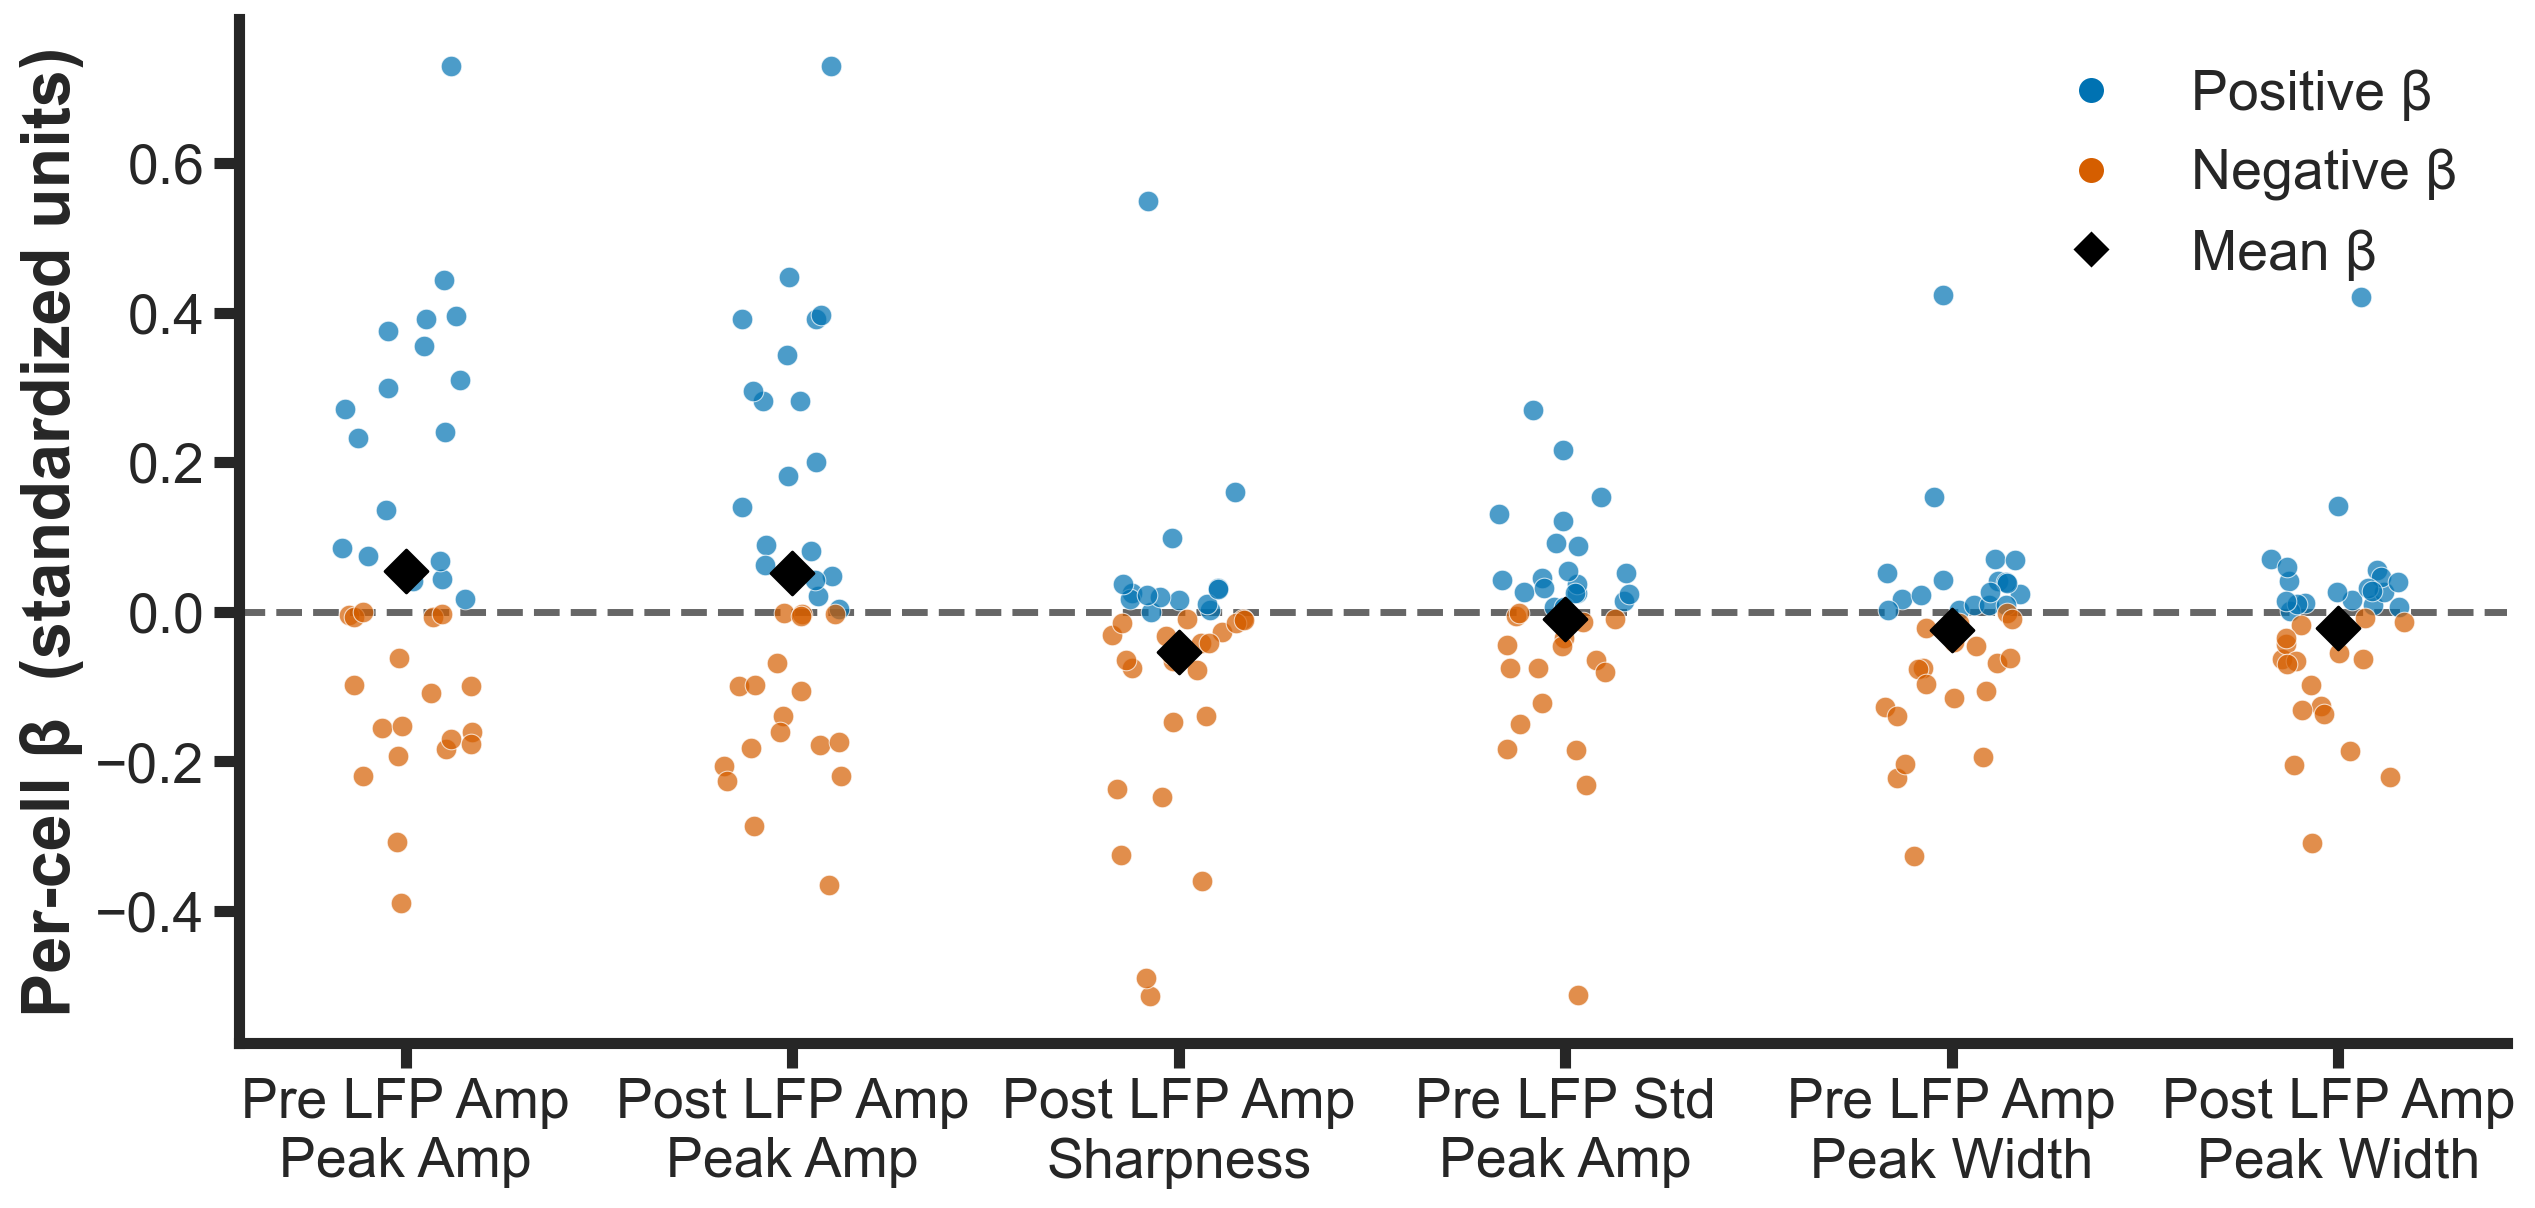

(<Figure size 1320x650 with 1 Axes>,
 <Axes: ylabel='Per-cell β  (standardized units)'>)

In [4]:
plot_beta_heterogeneity_top_combos(beta_pop, target_names, target_labels, n_top=6)

---
## Figure caption (draft)

**Supplementary Figure X. Ridge regression details.**

*[Caption placeholder — fill in after reviewing output.]*

## Panel C — Pre vs post-spike β correlation across cells

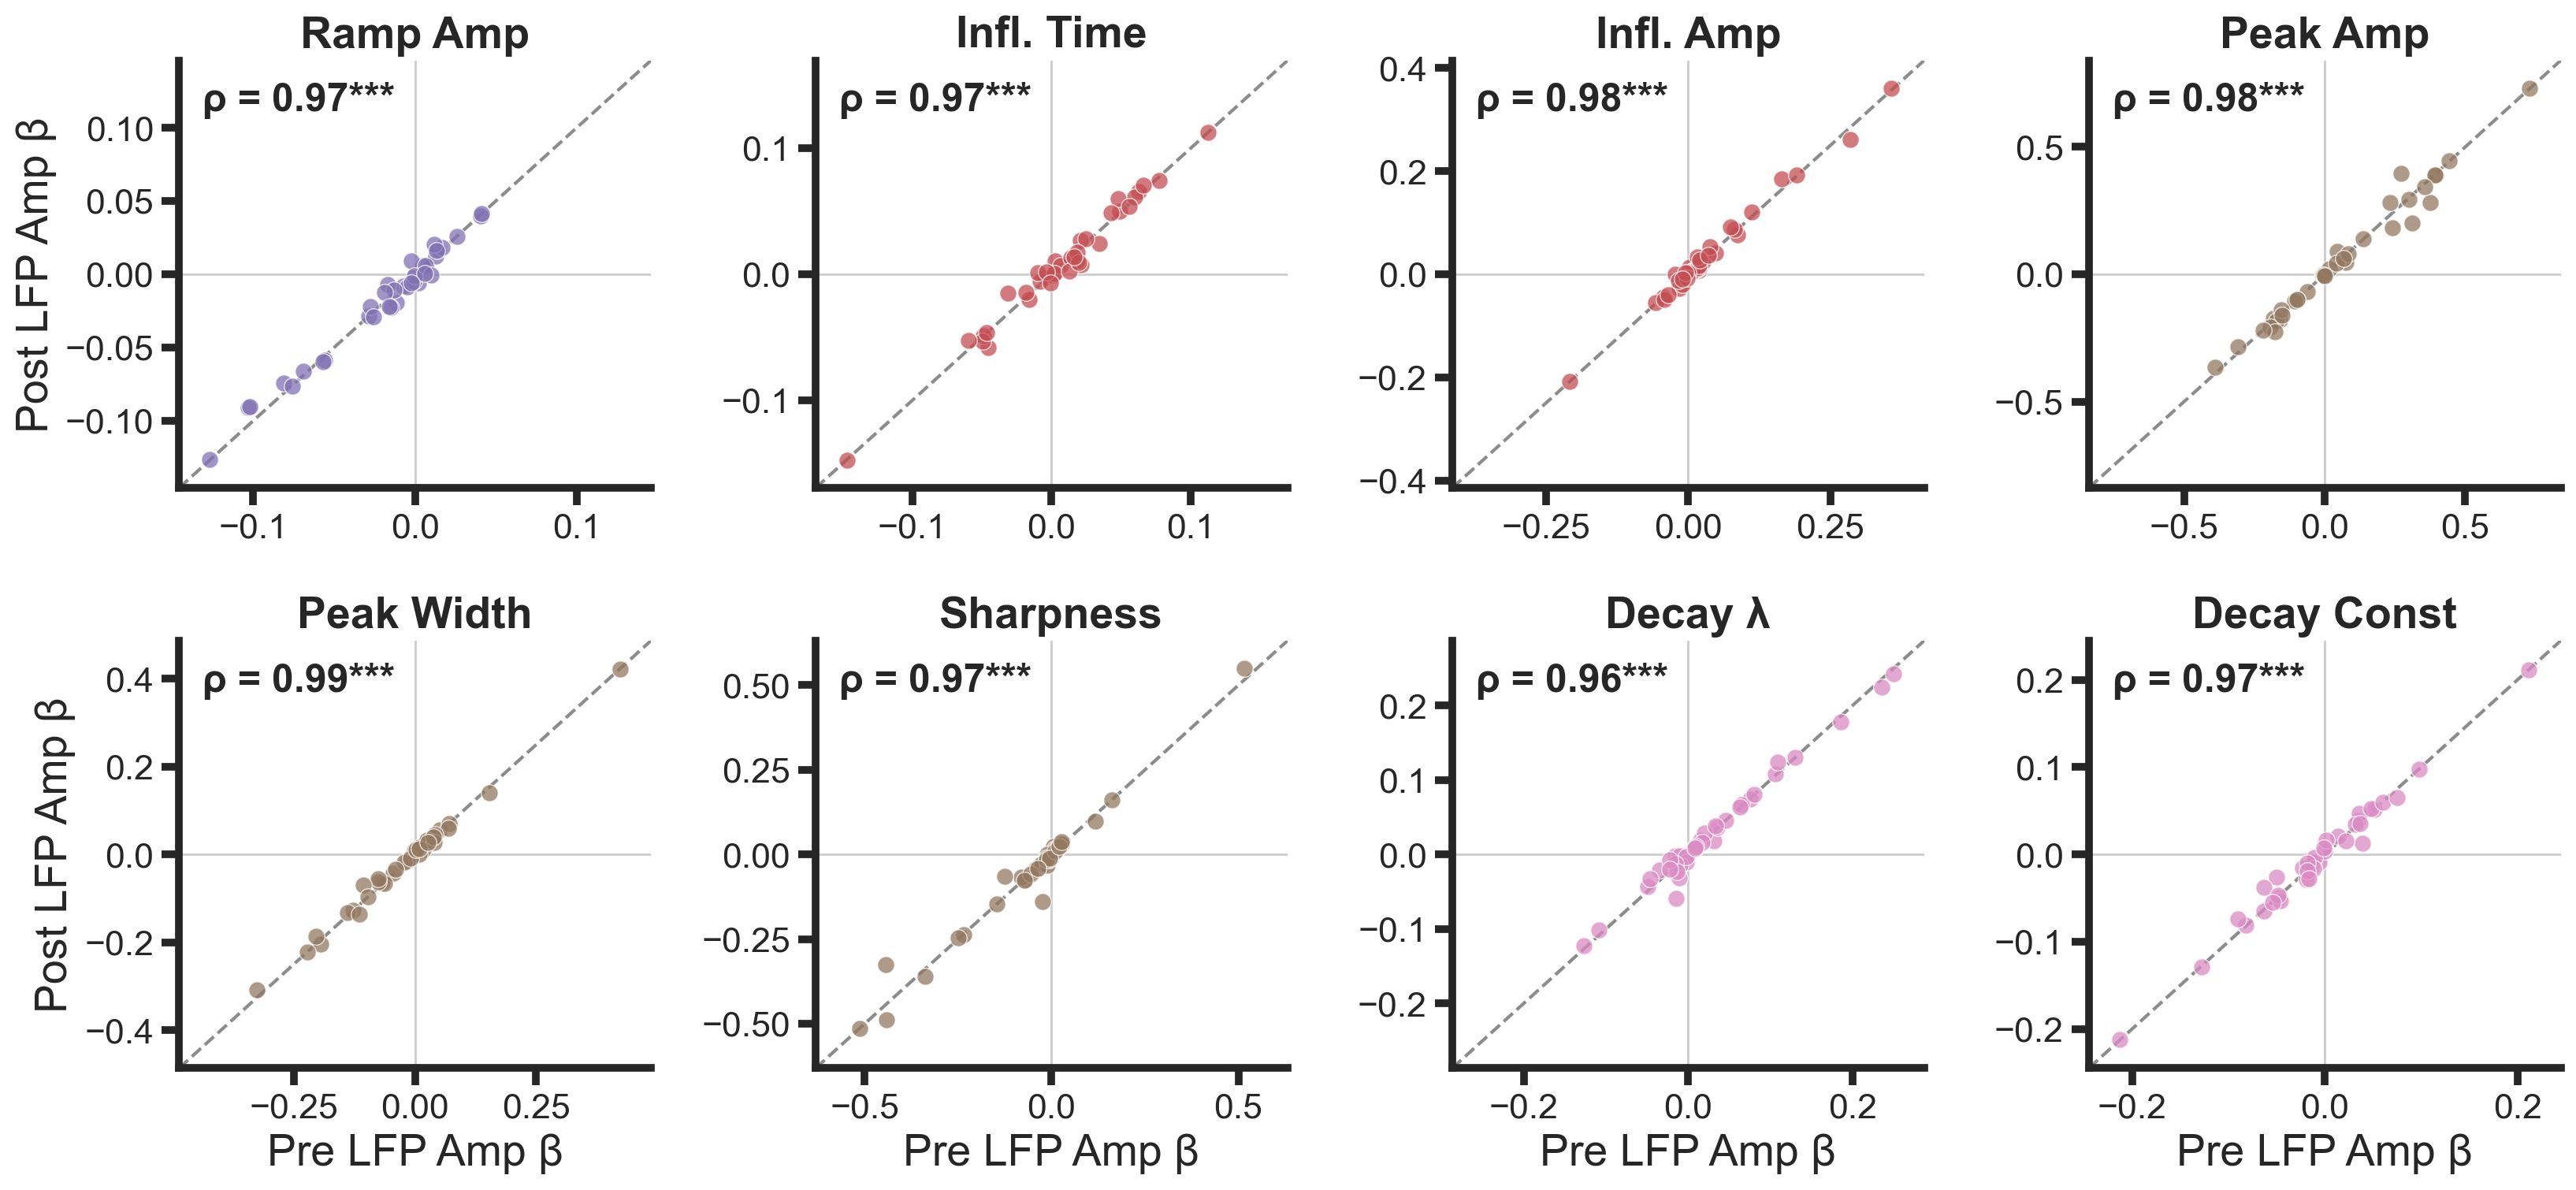

(<Figure size 1680x800 with 8 Axes>,
 array([<Axes: title={'center': 'Ramp Amp'}, ylabel='Post LFP Amp β'>,
        <Axes: title={'center': 'Infl. Time'}>,
        <Axes: title={'center': 'Infl. Amp'}>,
        <Axes: title={'center': 'Peak Amp'}>,
        <Axes: title={'center': 'Peak Width'}, xlabel='Pre LFP Amp β', ylabel='Post LFP Amp β'>,
        <Axes: title={'center': 'Sharpness'}, xlabel='Pre LFP Amp β'>,
        <Axes: title={'center': 'Decay λ'}, xlabel='Pre LFP Amp β'>,
        <Axes: title={'center': 'Decay Const'}, xlabel='Pre LFP Amp β'>],
       dtype=object))

In [5]:
plot_beta_pre_post_scatter(beta_pop, target_names, target_labels,
                           pre_label='Pre LFP Amp', post_label='Post LFP Amp')